# SDNET2018

### Import packages and set paths

In [29]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "sdnet2018"
FRACTURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "concrete_tbf"
    / "fracture_data.xlsx"
)

SURFACES = ["deck", "pavement", "wall"]
LABELS = ["crack", "uncrack"]

print(f"SDNET2018 path: {DATASET_DIR}")
print(f"ConcreteTBF file: {FRACTURE_FILE}")

SDNET2018 path: c:\Users\yoolm\Documents\concrete-crack-and-fracture-analysis\data\raw\sdnet2018
ConcreteTBF file: c:\Users\yoolm\Documents\concrete-crack-and-fracture-analysis\data\raw\concrete_tbf\fracture_data.xlsx


### Explore SDNET2018 structure and count images

In [30]:
# Count images
records = []

for surface in SURFACES:
    for label in LABELS:

        folder = DATASET_DIR / surface / f"{label}_dataset"

        images = [
            p for p in folder.rglob("*")
            if p.is_file()
            and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]

        for image_path in images:
            records.append({
                "image_path": str(image_path),
                "surface": surface,
                "label": "cracked" if label == "crack" else "uncracked"
            })

image_metadata = pd.DataFrame(records)

print(f"Total images: {len(image_metadata):,}")
print()

print("Images by surface and class:")
print(
    pd.crosstab(
        image_metadata["surface"],
        image_metadata["label"]
    )
)

Total images: 56,092

Images by surface and class:
label     cracked  uncracked
surface                     
deck         2025      11595
pavement     2608      21726
wall         3851      14287


### Overall class distribution

           Count  Percentage
label                       
cracked     8484       15.13
uncracked  47608       84.87


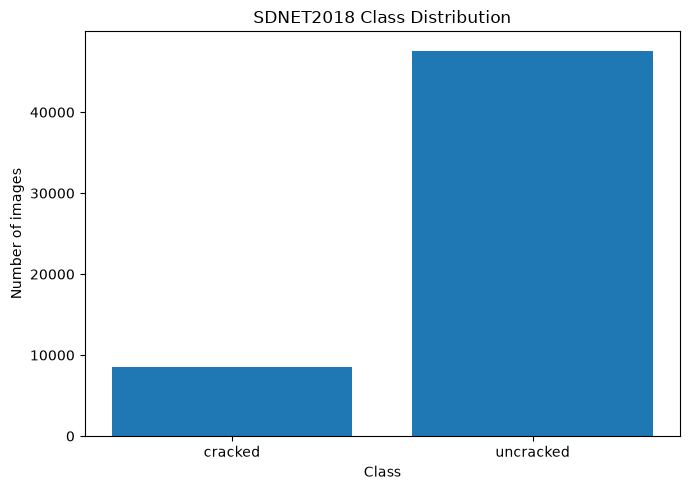

In [32]:
# Calculate class distribution
class_counts = (
    image_metadata["label"]
    .value_counts()
    .reindex(["cracked", "uncracked"])
)

class_percentages = (
    class_counts / class_counts.sum() * 100
).round(2)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

print(class_distribution)


# Plot class distribution
plt.figure(figsize=(7, 5))

plt.bar(
    class_distribution.index,
    class_distribution["Count"]
)

plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("SDNET2018 Class Distribution")

plt.tight_layout()
plt.show()

### Surface distribution

surface
deck        13620
pavement    24334
wall        18138
Name: count, dtype: int64


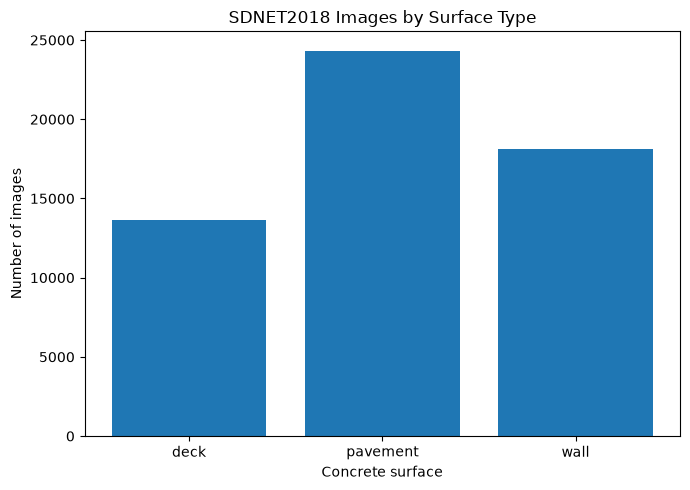

In [34]:
# Calculate surface distribution
surface_counts = (
    image_metadata["surface"]
    .value_counts()
    .reindex(SURFACES)
)

print(surface_counts)

# Plot surface distribution
plt.figure(figsize=(7, 5))

plt.bar(
    surface_counts.index,
    surface_counts.values
)

plt.xlabel("Concrete surface")
plt.ylabel("Number of images")
plt.title("SDNET2018 Images by Surface Type")

plt.tight_layout()
plt.show()

### Class distribution by surface

label     cracked  uncracked
surface                     
deck         2025      11595
pavement     2608      21726
wall         3851      14287


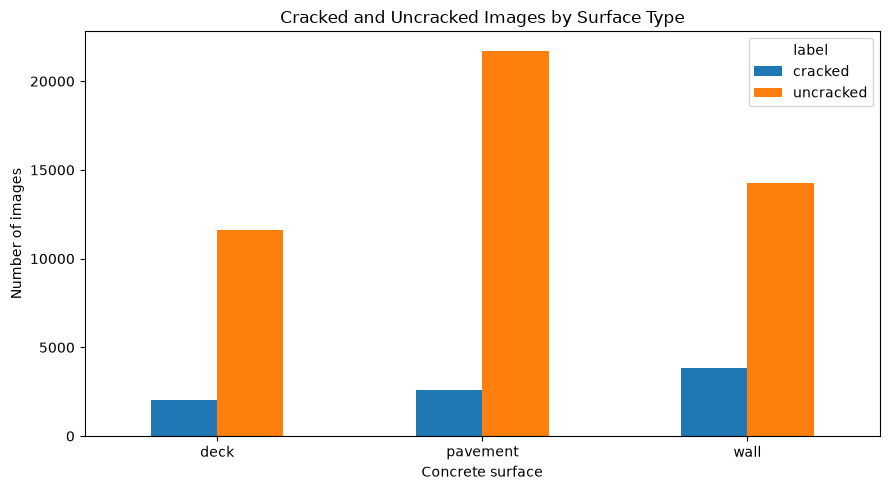

In [35]:
# Calculate class distribution by surface
surface_class = pd.crosstab(
    image_metadata["surface"],
    image_metadata["label"]
).reindex(
    index=SURFACES,
    columns=["cracked", "uncracked"]
)

print(surface_class)

# Plot class distribution by surface
surface_class.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Concrete surface")
plt.ylabel("Number of images")
plt.title("Cracked and Uncracked Images by Surface Type")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### image dimensions and channels

In [36]:
# Sample images for dimension inspection
sample_metadata = image_metadata.sample(
    n=min(300, len(image_metadata)),
    random_state=42
)

image_properties = []

for _, row in sample_metadata.iterrows():

    image = cv2.imread(row["image_path"])

    if image is None:
        image_properties.append({
            "width": None,
            "height": None,
            "channels": None,
            "readable": False
        })
        continue

    height, width = image.shape[:2]

    channels = (
        image.shape[2]
        if len(image.shape) == 3
        else 1
    )

    image_properties.append({
        "width": width,
        "height": height,
        "channels": channels,
        "readable": True
    })

properties_df = pd.DataFrame(image_properties)

print("Image dimensions:")
print(properties_df[["width", "height"]].value_counts())

print()
print("Channel distribution:")
print(properties_df["channels"].value_counts())

print()
print("Unreadable images:")
print((~properties_df["readable"]).sum())

Image dimensions:
width  height
256    256       300
Name: count, dtype: int64

Channel distribution:
channels
3    300
Name: count, dtype: int64

Unreadable images:
0


### Display representative images

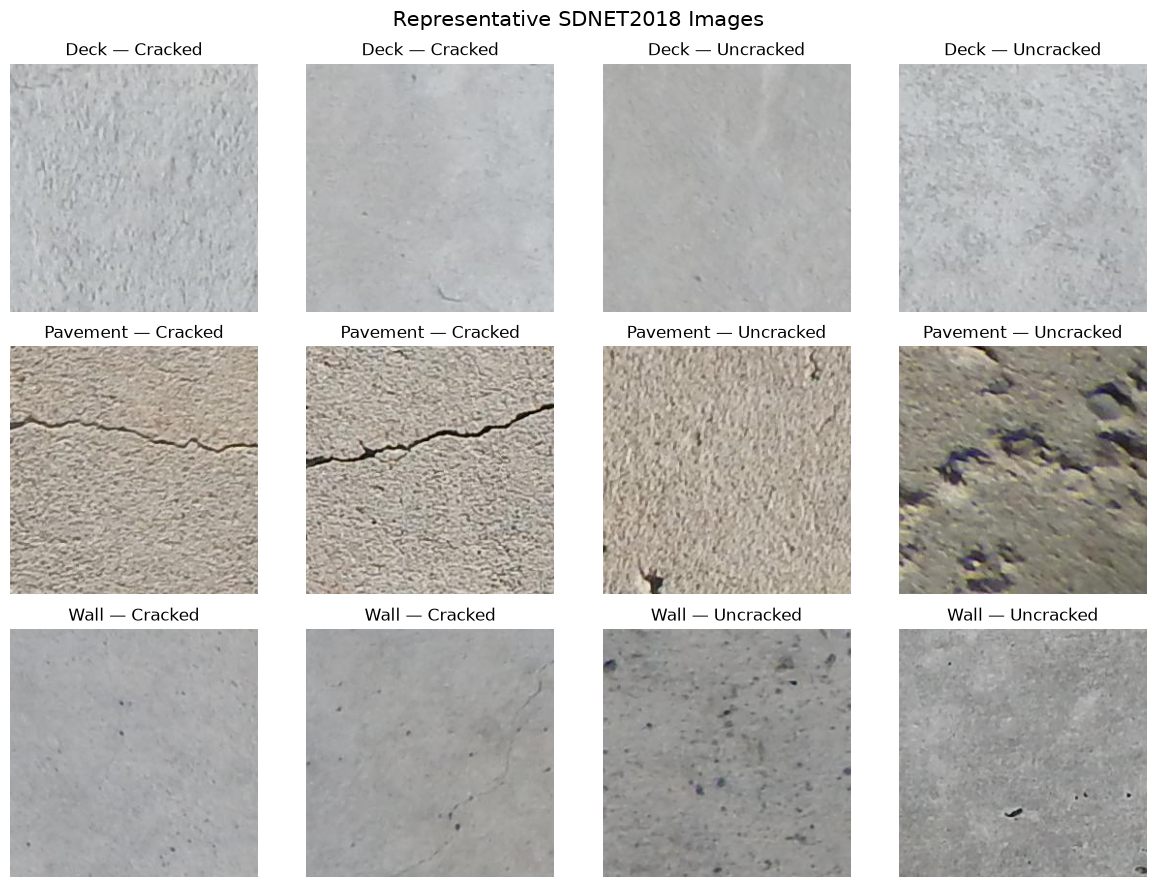

In [38]:
# Select representative images
samples = []

for surface in SURFACES:
    for label in ["cracked", "uncracked"]:

        subset = image_metadata[
            (image_metadata["surface"] == surface)
            & (image_metadata["label"] == label)
        ]

        samples.append(
            subset.sample(
                n=2,
                random_state=42
            )
        )

sample_images = pd.concat(samples)

# Display representative images
fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9)
)

for ax, (_, row) in zip(
    axes.flat,
    sample_images.iterrows()
):

    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image)
    ax.set_title(
        f'{row["surface"].capitalize()} — '
        f'{row["label"].capitalize()}'
    )
    ax.axis("off")

plt.suptitle(
    "Representative SDNET2018 Images",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Save the image metadata

In [39]:
# Save image metadata
METADATA_DIR = PROJECT_ROOT / "data" / "metadata"
METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

metadata_file = (
    METADATA_DIR / "image_metadata.csv"
)

image_metadata.to_csv(
    metadata_file,
    index=False
)

print(f"Metadata saved to: {metadata_file}")

Metadata saved to: c:\Users\yoolm\Documents\concrete-crack-and-fracture-analysis\data\metadata\image_metadata.csv


# ConcreteTBF

### Load ConcreteTBF

In [40]:
# load fracture data
fracture_data = pd.read_excel(FRACTURE_FILE)

print(f"rows:{fracture_data.shape[0]}, columns:{fracture_data.shape[1]}")

fracture_data.head()

rows:330, columns:8


,d (mm),S (mm),bw (mm),a0 (mm),Gc (N/mm),ft (MPa),E (GPa),Pult (kN)
0,250,800,100,125,0.070000,3.350000,27.203200,5.543000
1,360,900,250,160,0.073000,3.380000,27.324751,29.448743
2,310,1200,190,110,0.054000,3.660000,28.434029,15.215605
3,290,1000,170,120,0.069100,4.130000,30.204586,14.206183
4,280,700,200,85,0.060767,3.406667,27.432329,27.798306


### inspect dataset structure

In [41]:
# inspect fracture dataset structure
fracture_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   d (mm)     330 non-null    int64  
 1   S (mm)     330 non-null    int64  
 2   bw (mm)    330 non-null    int64  
 3   a0 (mm)    330 non-null    int64  
 4   Gc (N/mm)  330 non-null    float64
 5   ft (MPa)   330 non-null    float64
 6   E (GPa)    330 non-null    float64
 7   Pult (kN)  330 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 20.8 KB


### check Variable names

In [42]:
# display variable names
print(fracture_data.columns.tolist())

['d (mm)', 'S (mm)', 'bw (mm)', 'a0 (mm)', 'Gc (N/mm)', 'ft (MPa)', 'E (GPa)', 'Pult (kN)']


### Missing values and duplicates

In [43]:
# Check missing values
print("Missing values:")
print(fracture_data.isnull().sum())

print()

# Check duplicate rows
print(f"Duplicate rows: {fracture_data.duplicated().sum()}")

Missing values:
d (mm)       0
S (mm)       0
bw (mm)      0
a0 (mm)      0
Gc (N/mm)    0
ft (MPa)     0
E (GPa)      0
Pult (kN)    0
dtype: int64

Duplicate rows: 0


### Descriptive statistics

In [44]:
# calculate descriptive statistics
fracture_statistics = fracture_data.describe().T
fracture_statistics

,count,mean,std,min,25%,50%,75%,max
d (mm),330.0,214.909091,88.828021,50.000,150.000000,200.000000,300.000000,400.000000
S (mm),330.0,746.878788,315.443602,125.000,525.000000,750.000000,1000.000000,1300.000000
bw (mm),330.0,124.893939,60.051176,30.000,80.000000,110.000000,170.000000,250.000000
a0 (mm),330.0,68.187879,43.706202,4.000,31.250000,60.000000,98.750000,180.000000
Gc (N/mm),330.0,0.066410,0.027777,0.010,0.042600,0.065000,0.085000,0.141000
ft (MPa),330.0,3.550333,0.825348,1.800,3.000000,3.550000,4.285000,6.000000
E (GPa),330.0,28.265263,3.878233,19.000,25.785723,28.101906,30.882609,37.000000
Pult (kN),330.0,10.912512,8.053129,0.447,4.395490,8.605555,15.644877,32.335983


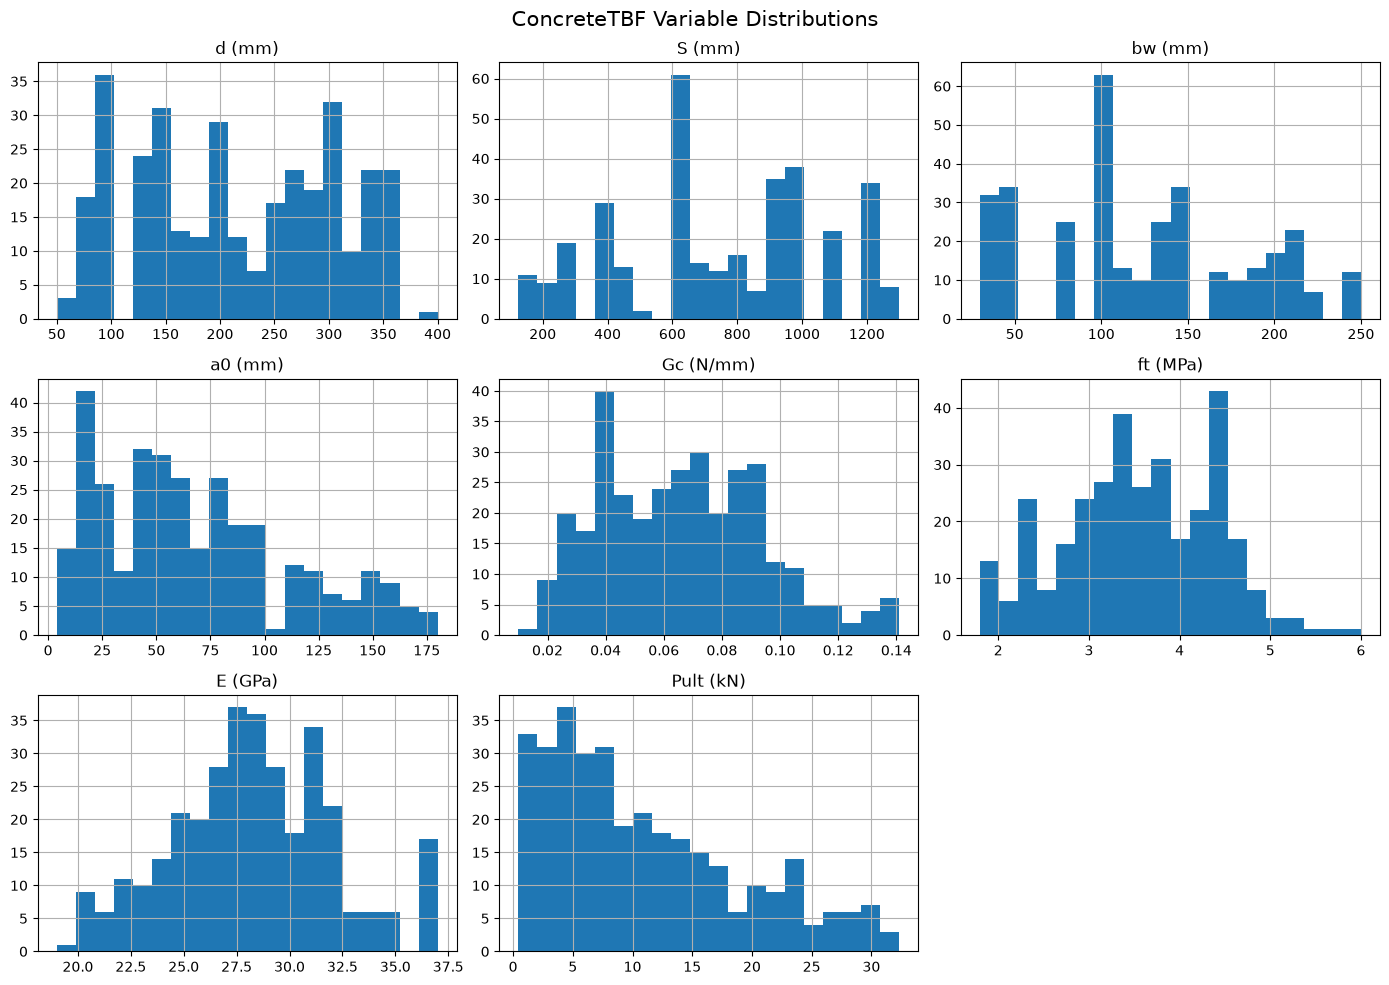

In [51]:
# Plot variable distributions
fracture_data.hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "ConcreteTBF Variable Distributions",
    fontsize=15
)

plt.tight_layout()
plt.show()

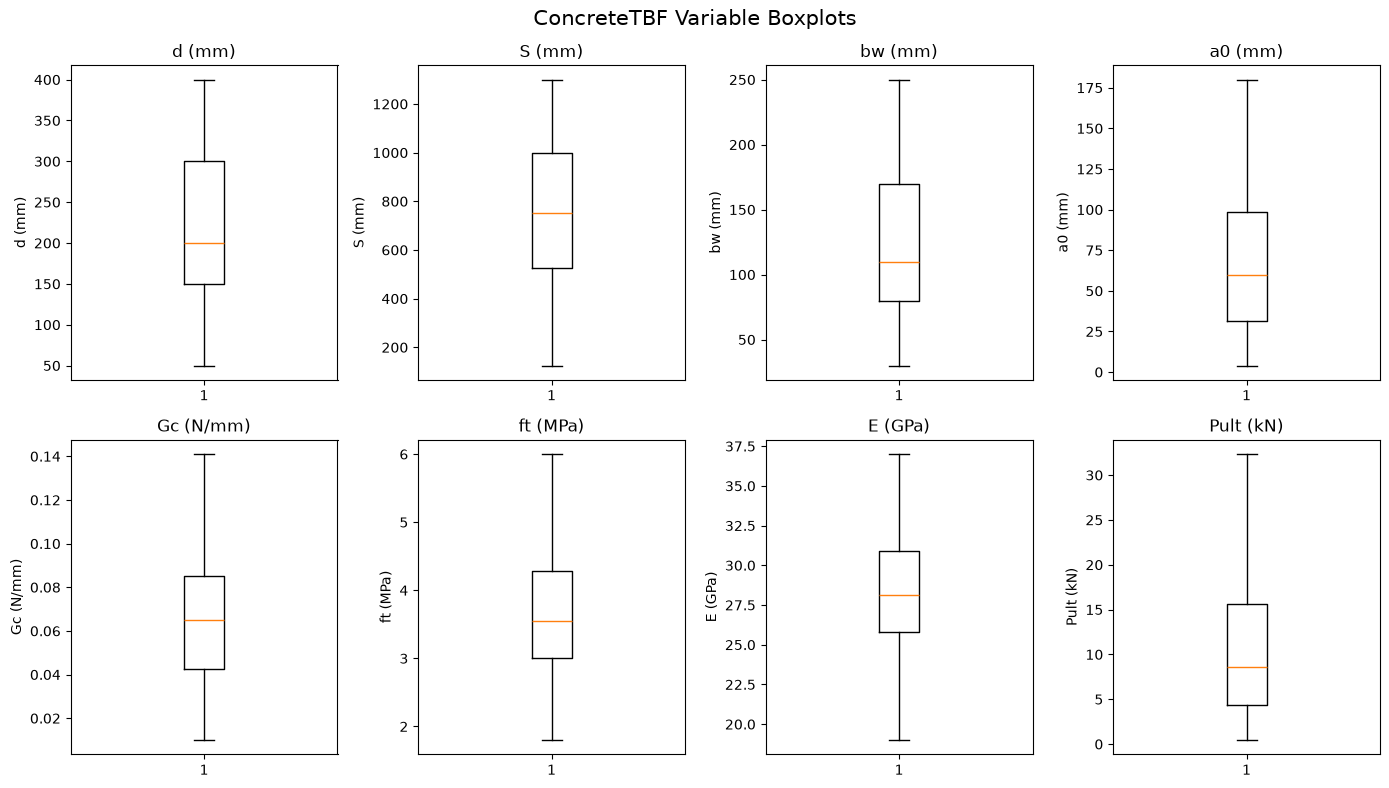

In [53]:
# Plot boxplots
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8)
)

for ax, column in zip(
    axes.flat,
    fracture_data.columns
):

    ax.boxplot(
        fracture_data[column]
    )

    ax.set_title(column)
    ax.set_ylabel(column)

plt.suptitle(
    "ConcreteTBF Variable Boxplots",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Correlation matrix

In [47]:
# Calculate correlation matrix
correlation_matrix = fracture_data.corr(
    numeric_only=True
)

correlation_matrix


,d (mm),S (mm),bw (mm),a0 (mm),Gc (N/mm),ft (MPa),E (GPa),Pult (kN)
d (mm),1.000000,0.898027,0.696168,0.701397,0.012684,0.172162,0.038334,0.784794
S (mm),0.898027,1.000000,0.677179,0.584126,0.110384,0.063085,-0.085701,0.636230
bw (mm),0.696168,0.677179,1.000000,0.564492,-0.054029,0.149131,0.002863,0.747977
a0 (mm),0.701397,0.584126,0.564492,1.000000,0.115467,0.037837,-0.038277,0.318508
Gc (N/mm),0.012684,0.110384,-0.054029,0.115467,1.000000,-0.283417,-0.256698,-0.036221
ft (MPa),0.172162,0.063085,0.149131,0.037837,-0.283417,1.000000,0.827978,0.318120
E (GPa),0.038334,-0.085701,0.002863,-0.038277,-0.256698,0.827978,1.000000,0.183831
Pult (kN),0.784794,0.636230,0.747977,0.318508,-0.036221,0.318120,0.183831,1.000000


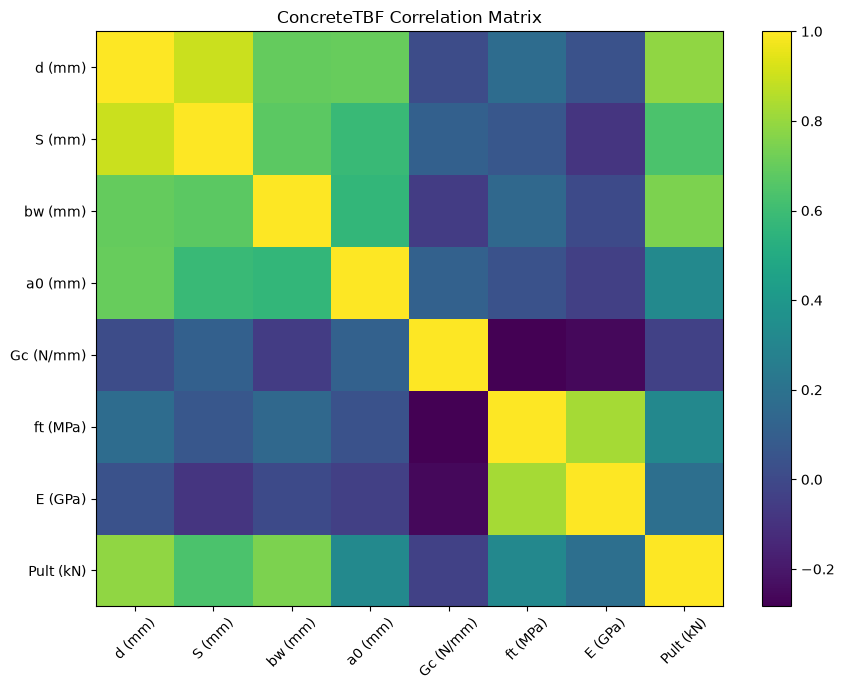

In [48]:
# Plot correlation matrix
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("ConcreteTBF Correlation Matrix")

plt.tight_layout()
plt.show()